# Synthetic vs Original Mammogram Classifier (PNG vs PNG)

**Objective**: Train a CNN classifier to distinguish between synthetic and original mammograms using converted PNG files for fair comparison.

**Expected Results**: Realistic accuracy ~50-60% (indicating genuine difficulty, no format bias)

In [1]:
# Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
import matplotlib.pyplot as plt
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# For imshow function
from matplotlib.pyplot import imshow

2025-10-19 15:37:36.003889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760902656.021972 3743778 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760902656.027554 3743778 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760902656.041165 3743778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760902656.041182 3743778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760902656.041184 3743778 computation_placer.cc:177] computation placer alr

In [2]:
# Data setup
DATAFOLDER = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/classifier_data'

os.makedirs(f'{DATAFOLDER}/train/synthetic', exist_ok=True)
os.makedirs(f'{DATAFOLDER}/train/original', exist_ok=True)
os.makedirs(f'{DATAFOLDER}/test/synthetic', exist_ok=True)
os.makedirs(f'{DATAFOLDER}/test/original', exist_ok=True)

In [3]:
# Organize files
synthetic_files = glob.glob('/raid/mpsych/OMAMA/DATA/data/train/*.png')
original_files = glob.glob('/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original/*.png')

# Use full dataset for research paper
print(f"Full dataset - Synthetic files: {len(synthetic_files)}")
print(f"Full dataset - Original files: {len(original_files)}")

# Split data
synthetic_train, synthetic_test = train_test_split(synthetic_files, test_size=0.2, random_state=42)
original_train, original_test = train_test_split(original_files, test_size=0.2, random_state=42)

# Clear existing files
for folder in [f'{DATAFOLDER}/train/synthetic', f'{DATAFOLDER}/train/original', 
               f'{DATAFOLDER}/test/synthetic', f'{DATAFOLDER}/test/original']:
    if os.path.exists(folder):
        for file in os.listdir(folder):
            file_path = os.path.join(folder, file)
            if os.path.islink(file_path):
                os.unlink(file_path)
            else:
                os.remove(file_path)

# Create symlinks
for file_path in synthetic_train:
    filename = os.path.basename(file_path)
    os.symlink(file_path, f'{DATAFOLDER}/train/synthetic/{filename}')

for file_path in synthetic_test:
    filename = os.path.basename(file_path)
    os.symlink(file_path, f'{DATAFOLDER}/test/synthetic/{filename}')

for file_path in original_train:
    filename = os.path.basename(file_path)
    os.symlink(file_path, f'{DATAFOLDER}/train/original/{filename}')

for file_path in original_test:
    filename = os.path.basename(file_path)
    os.symlink(file_path, f'{DATAFOLDER}/test/original/{filename}')

Full dataset - Synthetic files: 99999
Full dataset - Original files: 163568


In [4]:
# Data generators with aggressive augmentation to prevent overfitting
train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
X_train = train_generator.flow_from_directory(DATAFOLDER+'/train',
                                              color_mode='grayscale',
                                              target_size=(512,512),
                                              batch_size=32)

test_generator = ImageDataGenerator(rescale=1./255)
X_test = test_generator.flow_from_directory(DATAFOLDER+'/test',
                                            color_mode='grayscale',
                                            target_size=(512,512),
                                            batch_size=32)

Found 210853 images belonging to 2 classes.
Found 52714 images belonging to 2 classes.


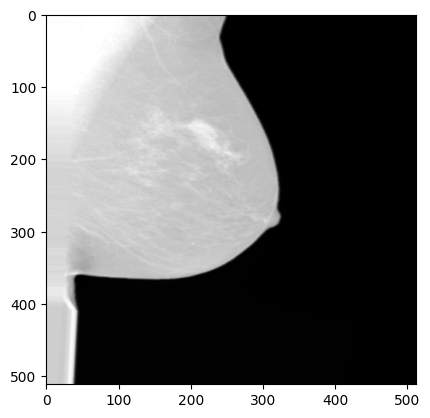

First label: [1. 0.]
Image max: 1.0
Image shape: (512, 512, 1)


In [5]:
# Check data
first_image = X_train[0][0][0]
first_label = X_train[0][1][0]

imshow(first_image[:,:,0], cmap='gray')
plt.show()

print(f"First label: {first_label}")
print(f"Image max: {first_image.max()}")
print(f"Image shape: {first_image.shape}")

In [6]:
# Model architecture with aggressive regularization to prevent overfitting
NUMBER_OF_CLASSES = 2

model = keras.models.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=(3, 3),
                             activation='relu',
                             input_shape=first_image.shape))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.GlobalAveragePooling2D())  # Instead of Flatten
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.8))  # Very high dropout
model.add(keras.layers.Dense(NUMBER_OF_CLASSES, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # Lower learning rate
              metrics=['accuracy'])

/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1760902975.425178 3743778 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:47:00.0, compute capability: 8.0


In [ ]:
# Training with aggressive early stopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=2,  # More aggressive - stop after 2 epochs without improvement
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,  # More aggressive learning rate reduction
    patience=1,  # Reduce LR after 1 epoch without improvement
    min_lr=0.00001,
    verbose=1
)

history = model.fit(X_train, 
                   epochs=15,  # Fewer epochs with aggressive early stopping
                   validation_data=X_test, 
                   callbacks=[early_stopping, reduce_lr],
                   verbose=1)

/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
4068/6590 ━━━━━━━━━━━━━━━━━━━━ 19:56 474ms/step - accuracy: 0.9985 - loss: 0.0039

Epoch 1/15


I0000 00:00:1760902979.958982 3748704 service.cc:152] XLA service 0x7f54f0005fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760902979.959018 3748704 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-10-19 15:43:00.050449: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1760902980.595409 3748704 cuda_dnn.cc:529] Loaded cuDNN version 90300
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName
2025-10-19 15:43:15.017169: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng23{k2=6,k13=0,k14=2,k18=1,k23=0} for conv %cudnn-conv-bw-filter.6 = (f32[32,1,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,512,512]{3,2,1,0} %bitcast.14956, f32[32,32,510,510]{3,2,1,0} %bitcast.15588), window=

   1/6590 ━━━━━━━━━━━━━━━━━━━━ 55:18:10 30s/step - accuracy: 0.5000 - loss: 1.5910

I0000 00:00:1760903007.747735 3748704 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2863/6590 ━━━━━━━━━━━━━━━━━━━━ 31:19 504ms/step - accuracy: 0.9791 - loss: 0.0578

KeyboardInterrupt: 

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Training')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Model evaluation
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = X_test.classes

test_accuracy = np.mean(predicted_classes == true_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix with better colors and visibility
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))

# Use a better colormap with higher contrast
im = plt.imshow(cm, interpolation='nearest', cmap='RdYlBu_r', aspect='auto')
plt.title('Confusion Matrix - Synthetic vs Original Mammograms', fontsize=16, fontweight='bold')
plt.colorbar(im, fraction=0.046, pad=0.04)

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Synthetic', 'Original'], fontsize=14)
plt.yticks(tick_marks, ['Synthetic', 'Original'], fontsize=14)
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')

# Add text annotations with better contrast
total = cm.sum()
for i, j in np.ndindex(cm.shape):
    # Calculate percentage
    percentage = (cm[i, j] / total) * 100
    # Use black text for better visibility
    plt.text(j, i, f'{cm[i, j]}\n({percentage:.1f}%)', 
             ha="center", va="center", fontsize=12, fontweight='bold',
             color="black")

plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(true_classes, predicted_classes, 
                          target_names=['Synthetic', 'Original']))